In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from IPython.display import display

%matplotlib inline
np.random.seed(42)  # for reproducibility


In [22]:
# 1. Load a simple real dataset (Iris) and define a Bernoulli variable
iris_data_frame = load_iris(as_frame=True)
X = iris_data_frame.data
y = iris_data_frame.target  # 0 = setosa, 1 = versicolor, 2 = virginica
target_names = iris_data_frame.target_names

# display(iris_data_frame.frame)

# Convert the multiclass target variable into a binary variable for "Setosa" vs "Not Setosa"
is_setosa = (y == 0).astype(int)


n_samples = len(is_setosa)
n_setosa = is_setosa.sum()

p_hat = n_setosa / n_samples

print("Unique classes in target variable:", target_names, y.unique())
print(f"Total flowers in dataset: {n_samples}")
print(f"Number of Setosa flowers (successes): {n_setosa}")
print(f"Empirical success probability p ≈ {p_hat:.3f}")


Unique classes in target variable: ['setosa' 'versicolor' 'virginica'] [0 1 2]
Total flowers in dataset: 150
Number of Setosa flowers (successes): 50
Empirical success probability p ≈ 0.333


In [30]:
# 2. Simulate a Binomial(n, p) random variable using numpy
n = 10              # number of flowers in each random sample
p = p_hat           # success probability estimated from data
n_experiments = 10000

# Each experiment: pick n flowers independently with probability p of being Setosa
# and count how many are Setosa. This count follows Binomial(n, p).
samples = np.random.binomial(n=n, p=p, size=20)
geometric_samples = np.random.geometric(p=p, size=20)


display(samples[:10])  # show first 10 simulated counts of Setosa in samples of size n
display(geometric_samples)  # show first 10 simulated geometric samples
# Empirical mean and variance from simulation
emp_mean = samples.mean()
emp_var = samples.var(ddof=0)

# Theoretical mean and variance of Binomial(n, p)
theo_mean = n * p
theo_var = n * p * (1 - p)

print("Binomial(n, p) based on Iris Setosa probability")
print(f"n = {n}, p ≈ {p:.3f}")
print(f"Empirical mean from simulation     : {emp_mean:.3f}")
print(f"Theoretical mean n·p               : {theo_mean:.3f}")
print(f"Empirical variance from simulation : {emp_var:.3f}")
print(f"Theoretical variance n·p·(1-p)     : {theo_var:.3f}")


array([3, 5, 5, 3, 4, 4, 2, 2, 6, 4])

array([ 4,  2,  1,  1,  1,  3,  1,  4,  1,  1,  6,  4,  1,  5,  2,  5,  3,
        3, 13,  1])

Binomial(n, p) based on Iris Setosa probability
n = 10, p ≈ 0.333
Empirical mean from simulation     : 3.350
Theoretical mean n·p               : 3.333
Empirical variance from simulation : 2.228
Theoretical variance n·p·(1-p)     : 2.222


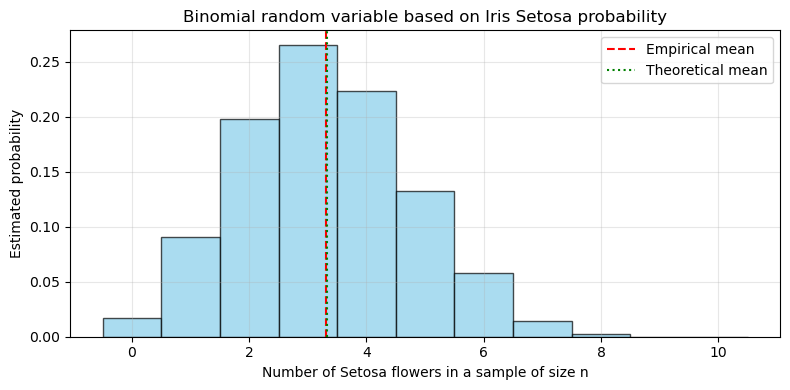

In [24]:
# 3. Visualize the Binomial distribution from the simulation
plt.figure(figsize=(8, 4))

bins = np.arange(-0.5, n + 1.5, 1)
plt.hist(samples, bins=bins, density=True,
         alpha=0.7, color='skyblue', edgecolor='black')

plt.axvline(emp_mean, color='red', linestyle='--', label='Empirical mean')
plt.axvline(theo_mean, color='green', linestyle=':', label='Theoretical mean')

plt.title('Binomial random variable based on Iris Setosa probability')
plt.xlabel('Number of Setosa flowers in a sample of size n')
plt.ylabel('Estimated probability')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
